<a href="https://colab.research.google.com/github/gretadive/correlacion_actividad_solar_elnino/blob/main/01_limpieza_icen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpieza y preparación de datos ICEN
## Fuente de datos
- Variable: Índice Costero El Niño (ICEN)
- Fuente: IMARPE / ENFEN
- Archivo original: `icen_original.txt`
- Ubicación en GitHub: `data/raw/ICEN/

In [ ]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

if token:
    print("✅ Token de GitHub cargado correctamente")
else:
    print("❌ No se pudo acceder al token")

✅ Token de GitHub cargado correctamente


In [ ]:
!ls /content/correlacion_actividad_solar_elnino


data  figures  notebooks  README.md  results  src


In [ ]:
%cd /content/correlacion_actividad_solar_elnino

/content/correlacion_actividad_solar_elnino


In [ ]:
!ls data/raw/ICEN

icen_original.txt  README.md


In [ ]:
import pandas as pd

df_icen = pd.read_csv(
    "data/raw/ICEN/icen_original.txt",
    sep=r"\s+",
    comment="%",
    names=["anio", "mes", "ICEN"]
)

df_icen.head()

,anio,mes,ICEN
0,1950,1,-0.75
1,1950,2,-1.07
2,1950,3,-1.25
3,1950,4,-1.18
4,1950,5,-1.22


In [ ]:
print("Dimensiones:", df_icen.shape)
print("\nTipos de datos:")
print(df_icen.dtypes)

print("\nValores faltantes:")
print(df_icen.isnull().sum())

print("\nFilas duplicadas:")
print(df_icen.duplicated().sum())

print("\nPrimer registro:")
print(df_icen.iloc[0])

print("\nÚltimo registro:")
print(df_icen.iloc[-1])

Dimensiones: (917, 3)

Tipos de datos:
anio      int64
mes       int64
ICEN    float64
dtype: object

Valores faltantes:
anio    0
mes     0
ICEN    0
dtype: int64

Filas duplicadas:
0

Primer registro:
anio    1950.00
mes        1.00
ICEN      -0.75
Name: 0, dtype: float64

Último registro:
anio    2026.00
mes        5.00
ICEN       1.98
Name: 916, dtype: float64


In [ ]:
df_icen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   anio    917 non-null    int64  
 1   mes     917 non-null    int64  
 2   ICEN    917 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 21.6 KB


In [ ]:
print("Total de registros:", len(df_icen))
print("Año mínimo:", df_icen["anio"].min())
print("Año máximo:", df_icen["anio"].max())
print("Valores nulos:", df_icen.isnull().sum().sum())
print("Filas duplicadas:", df_icen.duplicated().sum())

print("\nEstadísticas de ICEN:")
print(df_icen["ICEN"].describe())

Total de registros: 917
Año mínimo: 1950
Año máximo: 2026
Valores nulos: 0
Filas duplicadas: 0

Estadísticas de ICEN:
count    917.000000
mean       0.002737
std        1.018758
min       -2.230000
25%       -0.690000
50%       -0.200000
75%        0.490000
max        4.320000
Name: ICEN, dtype: float64


In [ ]:
df_icen["fecha"] = pd.to_datetime(
    dict(
        year=df_icen["anio"],
        month=df_icen["mes"],
        day=1
    )
)

df_icen = df_icen[["fecha", "anio", "mes", "ICEN"]]

df_icen.head()

,fecha,anio,mes,ICEN
0,1950-01-01,1950,1,-0.75
1,1950-02-01,1950,2,-1.07
2,1950-03-01,1950,3,-1.25
3,1950-04-01,1950,4,-1.18
4,1950-05-01,1950,5,-1.22


In [ ]:
# Ordenar cronológicamente
df_icen = df_icen.sort_values("fecha").reset_index(drop=True)

# Verificar fechas duplicadas
duplicadas = df_icen["fecha"].duplicated().sum()

# Verificar meses faltantes
fechas_esperadas = pd.date_range(
    start=df_icen["fecha"].min(),
    end=df_icen["fecha"].max(),
    freq="MS"
)

fechas_faltantes = fechas_esperadas.difference(df_icen["fecha"])

print("Registros:", len(df_icen))
print("Fechas duplicadas:", duplicadas)
print("Meses faltantes:", len(fechas_faltantes))
print("Periodo:", df_icen["fecha"].min(), "a", df_icen["fecha"].max())

Registros: 917
Fechas duplicadas: 0
Meses faltantes: 0
Periodo: 1950-01-01 00:00:00 a 2026-05-01 00:00:00


In [ ]:
ruta_salida = "data/processed/icen_procesado.csv"

df_icen.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8"
)

print("✅ Archivo guardado:", ruta_salida)

✅ Archivo guardado: data/processed/icen_procesado.csv


In [ ]:
!ls data/processed

icen_procesado.csv  README.md


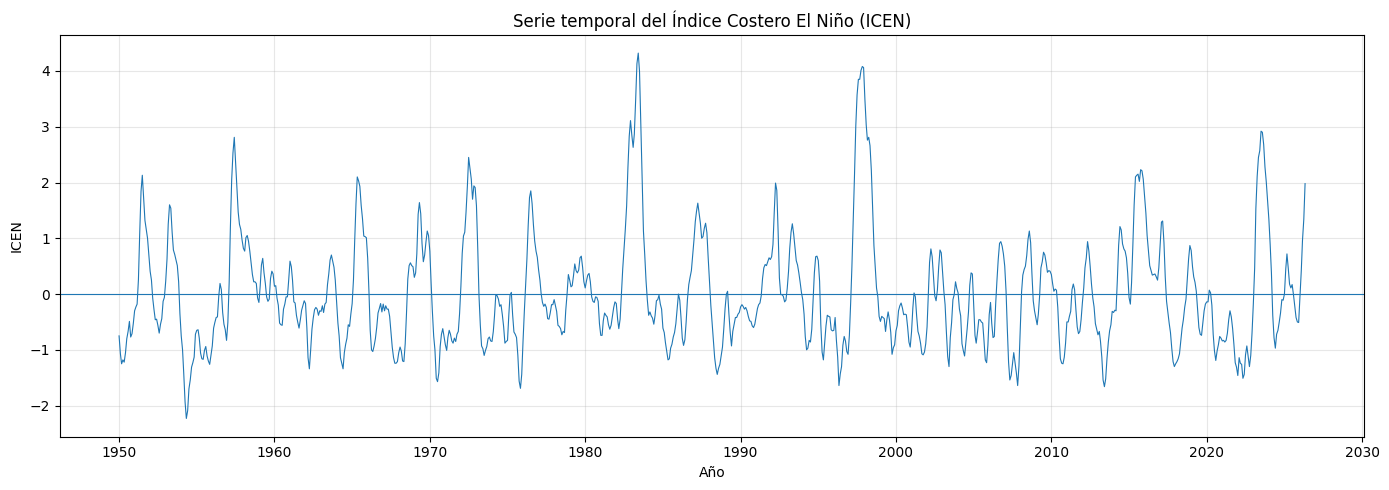

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df_icen["fecha"], df_icen["ICEN"], linewidth=0.8)

plt.axhline(0, linewidth=0.8)
plt.xlabel("Año")
plt.ylabel("ICEN")
plt.title("Serie temporal del Índice Costero El Niño (ICEN)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

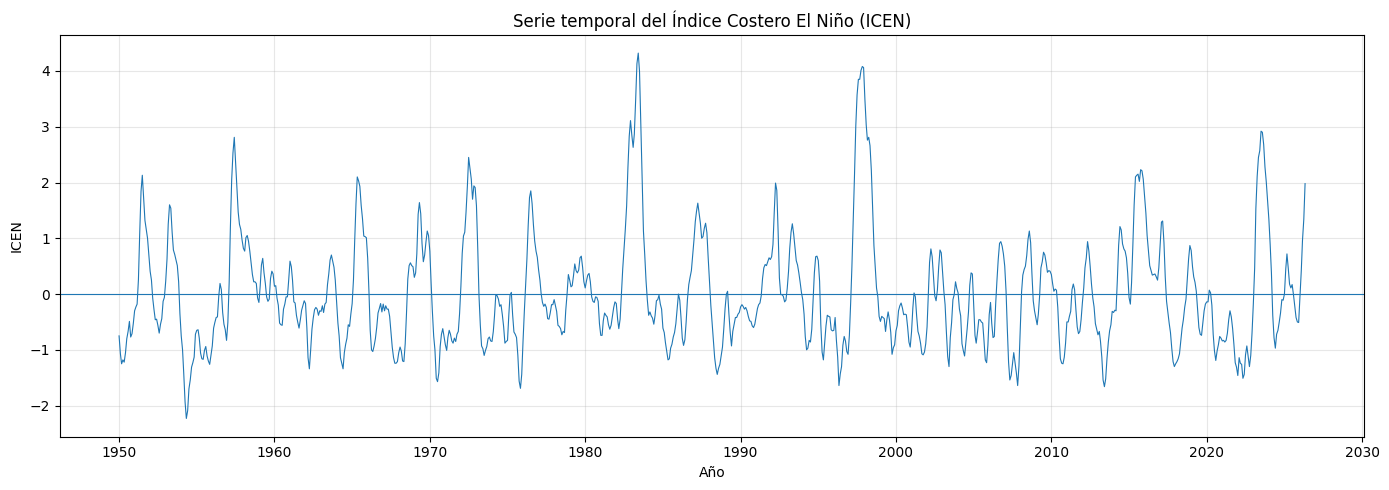

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_icen["fecha"], df_icen["ICEN"], linewidth=0.8)
plt.axhline(0, linewidth=0.8)
plt.xlabel("Año")
plt.ylabel("ICEN")
plt.title("Serie temporal del Índice Costero El Niño (ICEN)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/serie_temporal_icen.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/processed/icen_procesado.csv
	figures/serie_temporal_icen.png

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git config user.name "gretadive"
!git config user.email "gretadive@users.noreply.github.com"
!git add data/processed/icen_procesado.csv
!git add figures/serie_temporal_icen.png
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data/processed/icen_procesado.csv
	new file:   figures/serie_temporal_icen.png



In [ ]:
!git commit -m "Procesar datos ICEN y agregar serie temporal"

[main 37bd7da] Procesar datos ICEN y agregar serie temporal
 2 files changed, 918 insertions(+)
 create mode 100644 data/processed/icen_procesado.csv
 create mode 100644 figures/serie_temporal_icen.png


In [ ]:
from google.colab import userdata
import subprocess
import base64

token = userdata.get("GITHUB_TOKEN")
usuario = "gretadive"

credenciales = base64.b64encode(
    f"{usuario}:{token}".encode()
).decode()

resultado = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credenciales}",
        "push",
        "origin",
        "main"
    ],
    capture_output=True,
    text=True
)

if resultado.returncode == 0:
    print("✅ Cambios enviados correctamente a GitHub")
else:
    print("❌ Error al enviar los cambios")
    print(resultado.stderr)

✅ Cambios enviados correctamente a GitHub
